## EDS 232 - Homework 2, Task 1

### Non-linearity of the response-predictor relationship

    When using linear regression, we assume that the relationship between our predictor and response is linear. That is, the rate of change of our response variable is constant over our changing predictor variable. In reality, true linear relationships are rare, and using a linear regression model can often produce results that are meaningless to interpret. If you suspect that the relationship you're plotting is not linear, it's helpful to plot the residuals (error between predicted and actual values) of your dataset, and if necessary, make transformations to your X-axis (squaring, log(x)), to see if residuals can be reduced. 

    What kind of automation strategies are commonplace for finding the best x-axis tranformations to reduce residuals? Is there a way computers/mathematics can do this without just doing trial and error?

    In the figures below - The top row shows the raw data with each model's fit overlaid. It's already visually clear that the linear model (red line) misses the curve in the data, while the quadratic fit (green) tracks it well. In the bottom row the linear residual plot shows a U-shape, meaning the model is systematically wrong in a predictable way. The quadratic residuals scatter randomly around zero with no pattern, confirming the model has captured the true relationship in the data.


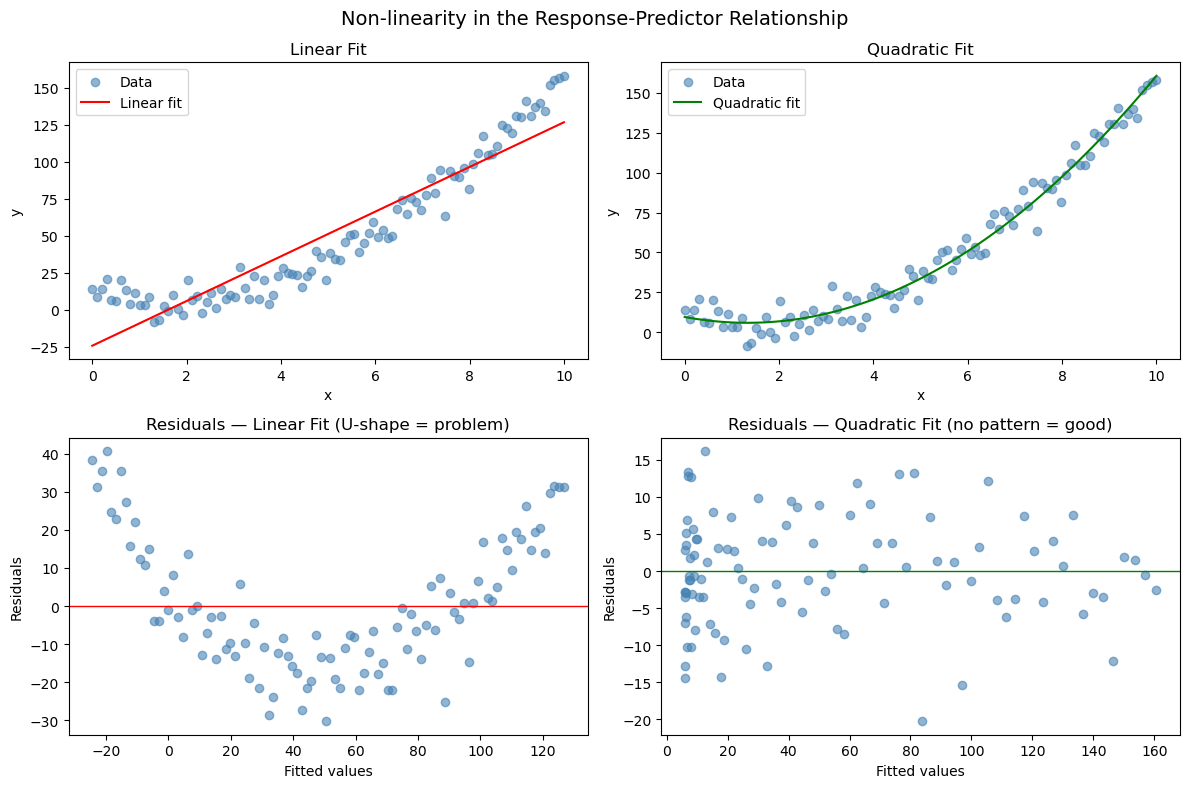

In [1]:
## Non-linearity code example
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)

# --- Generate fake non-linear data ---
x = np.linspace(0, 10, 100)
y = 2 * x**2 - 5 * x + 10 + np.random.normal(0, 8, size=len(x))

X = x.reshape(-1, 1)

# --- Fit linear model ---
lin_model = LinearRegression().fit(X, y)
y_pred_lin = lin_model.predict(X)
residuals_lin = y - y_pred_lin

# --- Fit quadratic model ---
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
quad_model = LinearRegression().fit(X_poly, y)
y_pred_quad = quad_model.predict(X_poly)
residuals_quad = y - y_pred_quad

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Non-linearity in the Response-Predictor Relationship", fontsize=14)

# Top-left: data + linear fit
axes[0, 0].scatter(x, y, alpha=0.6, color="steelblue", label="Data")
axes[0, 0].plot(x, y_pred_lin, color="red", label="Linear fit")
axes[0, 0].set_title("Linear Fit")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].legend()

# Top-right: data + quadratic fit
axes[0, 1].scatter(x, y, alpha=0.6, color="steelblue", label="Data")
axes[0, 1].plot(x, y_pred_quad, color="green", label="Quadratic fit")
axes[0, 1].set_title("Quadratic Fit")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
axes[0, 1].legend()

# Bottom-left: residuals from linear fit
axes[1, 0].scatter(y_pred_lin, residuals_lin, alpha=0.6, color="steelblue")
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title("Residuals — Linear Fit (U-shape = problem)")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("Residuals")

# Bottom-right: residuals from quadratic fit
axes[1, 1].scatter(y_pred_quad, residuals_quad, alpha=0.6, color="steelblue")
axes[1, 1].axhline(0, color="green", linewidth=1)
axes[1, 1].set_title("Residuals — Quadratic Fit (no pattern = good)")
axes[1, 1].set_xlabel("Fitted values")
axes[1, 1].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig("nonlinearity.png", dpi=150)
plt.show()



### Outliers

Outliers are data points that fall far outside the distribution majority of your sample - whether of measurement errors, or true anomalies. Outliers can have a dramatic and misleading effect on the value of statistics related to your data by skewing averages of error values and other fit statistics. Outliers can be identified by plotting residuals, and looking for values that have higher magnitude than the average of residuals. Dealing with outliers usually means identifying potential issues with data collection, or possibly modifying your model to account for anomalous values (like giving less weight to extreme values).

Question: How do different models give less weight to extreme values? 


Below, the left plot shows how even a few outliers visibly pull the fitted line away from the true relationship. The right plot shows the residual-based detection approach — points beyond ±2 standard deviations from zero stand out clearly as candidates for investigation.



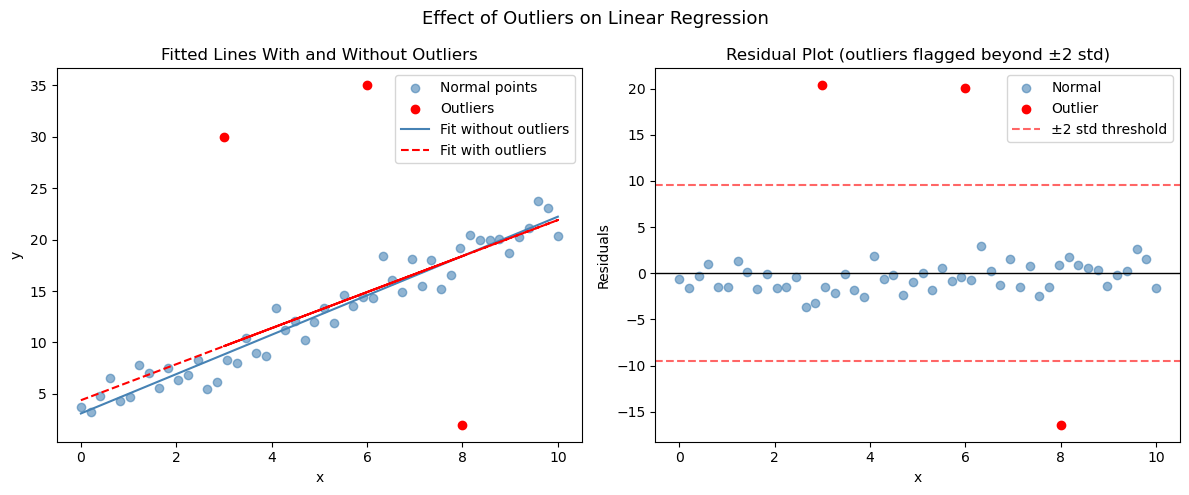

In [4]:

np.random.seed(42)
n = 50

# --- Generate clean linear data ---
x = np.linspace(0, 10, n)
y = 2 * x + 3 + np.random.normal(0, 1.5, n)

# --- Add a few outliers ---
x_out = np.append(x, [3, 6, 8])
y_out = np.append(y, [30, 35, 2])  # way off the true line

X = x.reshape(-1, 1)
X_out = x_out.reshape(-1, 1)

# --- Fit both models ---
model_clean = LinearRegression().fit(X, y)
model_out   = LinearRegression().fit(X_out, y_out)

y_pred_clean = model_clean.predict(X)
y_pred_out   = model_out.predict(X_out)
residuals    = y_out - y_pred_out

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Effect of Outliers on Linear Regression", fontsize=13)

# Left: fitted lines on data
axes[0].scatter(x, y, alpha=0.6, color="steelblue", label="Normal points")
axes[0].scatter([3, 6, 8], [30, 35, 2], color="red", zorder=5, label="Outliers")
axes[0].plot(x, y_pred_clean, color="steelblue", label="Fit without outliers")
axes[0].plot(x_out, y_pred_out, color="red", linestyle="--", label="Fit with outliers")
axes[0].set_title("Fitted Lines With and Without Outliers")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: residual plot with outliers flagged
threshold = 2 * np.std(residuals)
is_outlier = np.abs(residuals) > threshold

axes[1].scatter(x_out[~is_outlier], residuals[~is_outlier], color="steelblue", alpha=0.6, label="Normal")
axes[1].scatter(x_out[is_outlier],  residuals[is_outlier],  color="red", zorder=5, label="Outlier")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline( threshold, color="red", linestyle="--", alpha=0.6, label="±2 std threshold")
axes[1].axhline(-threshold, color="red", linestyle="--", alpha=0.6)
axes[1].set_title("Residual Plot (outliers flagged beyond ±2 std)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Residuals")
axes[1].legend()

plt.tight_layout()
plt.savefig("outliers.png", dpi=150)
plt.show()



### Collinearity

Collinearity refers to the instance where two predictors have a similar linear relationship with the response variable. This can make it difficult to separate the effects of each predictor on the response, as collinear predictor-response relationships will mask eachother. If we cannot isolate the effects of our individual predictors, then we won't be able to meaningfully quantify the relationship between either predictor and the response. Collinearity can be detected by looking at a correlation matrix of predictors, which will yield high, positive values if predictors are collinear. If two or more predictors are collinear, it is common practice to combine them into a single predictor, or remove one or more predictors from the model.

Question: How do we deal with collinearity that only exists for a single portion of our data distribution? Like, what if our predictors are collinear for the first 75% of our dataset, but then one of them takes on a x^2 or log(x) relationship with the reponse? variable.

Below, the first two plots illustrate the problem setup — age and limit have no real relationship, but rating and limit are collinear.
The lower row is the key diagnostic: by refitting the model on many bootstrap samples, we can see how stable each coefficient estimate is. The limit coefficient in the non-collinear model clusters tightly, while in the collinear model it spreads widely — the data can't pin down the individual effect of limit when rating is carrying almost the same information.

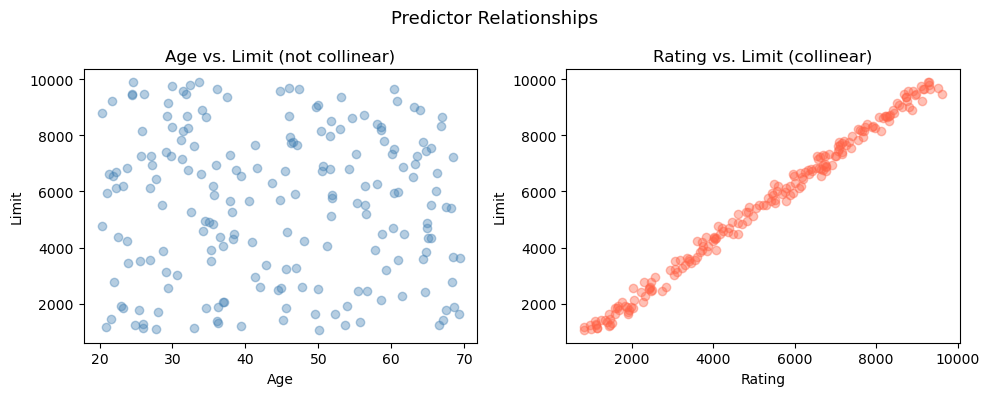

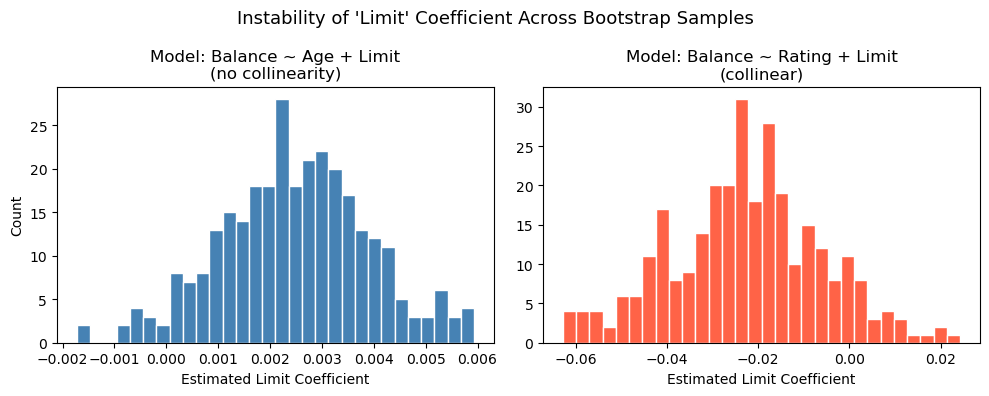

Limit coef std (no collinearity): 0.0014
Limit coef std (collinear):       0.0166


In [3]:
np.random.seed(42)
n = 200

# --- Generate synthetic data ---
age = np.random.uniform(20, 70, n)
limit = np.random.uniform(1000, 10000, n)
rating = 0.95 * limit + np.random.normal(0, 200, n)  # highly correlated with limit
balance = 0.003 * limit - 0.5 * age + np.random.normal(0, 50, n)

# --- Plot 1: Predictor relationships (collinear vs. not) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Predictor Relationships", fontsize=13)

axes[0].scatter(age, limit, alpha=0.4, color="steelblue")
axes[0].set_title("Age vs. Limit (not collinear)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Limit")

axes[1].scatter(rating, limit, alpha=0.4, color="tomato")
axes[1].set_title("Rating vs. Limit (collinear)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Limit")

plt.tight_layout()
plt.savefig("collinearity_predictors.png", dpi=150)
plt.show()

# --- Fit both models many times with bootstrap to show coefficient instability ---
n_boot = 300
coef_age_model = []    # limit coefficient from balance ~ age + limit
coef_rating_model = [] # limit coefficient from balance ~ rating + limit

for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    X1 = np.column_stack([age[idx], limit[idx]])
    X2 = np.column_stack([rating[idx], limit[idx]])
    y = balance[idx]

    coef_age_model.append(LinearRegression().fit(X1, y).coef_[1])      # limit coef
    coef_rating_model.append(LinearRegression().fit(X2, y).coef_[1])   # limit coef

# --- Plot 2: Coefficient instability ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Instability of 'Limit' Coefficient Across Bootstrap Samples", fontsize=13)

axes[0].hist(coef_age_model, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Model: Balance ~ Age + Limit\n(no collinearity)")
axes[0].set_xlabel("Estimated Limit Coefficient")
axes[0].set_ylabel("Count")

axes[1].hist(coef_rating_model, bins=30, color="tomato", edgecolor="white")
axes[1].set_title("Model: Balance ~ Rating + Limit\n(collinear)")
axes[1].set_xlabel("Estimated Limit Coefficient")

plt.tight_layout()
plt.savefig("collinearity_instability.png", dpi=150)
plt.show()

# --- Print VIF and std comparison ---
print(f"Limit coef std (no collinearity): {np.std(coef_age_model):.4f}")
print(f"Limit coef std (collinear):       {np.std(coef_rating_model):.4f}")

Reflection:

I used Claude to generate code, and a created a project specifically for this task. I gave instructions that only widely used packages and syntax should be used, and that things should not be too inventive or over-complicated, that I was just trying to generate visual to help interpret relatively simple concepts. The code worked on the first try in every case, but I find that the resulting figures are not particularly intuitive. In my prompts I provided the text from our textbook for each section to give it some background, and I think that extra-wordy prompt made it overthing and make visuals that were a bit too complicated. In the future I will probably ask for specifc figures instead of asking Claude to just "make figures that illustrate this concept". 